# Training Augmentation Experiment

## 1. Load a few training images

We will create small, realistic changes to training images in memory. We will not save augmented images or train a model.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms

# Find the project folder when this notebook runs from the repo or notebooks folder.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'processed' / 'final').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FINAL_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'final'
TRAIN_IMAGE_DIR = FINAL_ROOT / 'train' / 'images'


def simple_dataset_check():
    check = {}
    for split in ['train', 'valid', 'test']:
        image_dir = FINAL_ROOT / split / 'images'
        metadata = pd.read_csv(FINAL_ROOT / split / 'metadata.csv')
        check[split] = {
            'image_count': len(list(image_dir.iterdir())),
            'filenames': sorted(path.name for path in image_dir.iterdir()),
            'metadata_rows': len(metadata),
        }
    return check


before_check = simple_dataset_check()
sample_rows = pd.read_csv(FINAL_ROOT / 'train' / 'metadata.csv').head(6)

print('Training images:', before_check['train']['image_count'])
print('Validation images:', before_check['valid']['image_count'])
print('Test images:', before_check['test']['image_count'])
print('Loaded', len(sample_rows), 'training images.')

Training images: 10052
Validation images: 1084
Test images: 1067
Loaded 6 training images.


## 2. Define the augmentation transform

Training images get small random changes. Validation and test images use only the deterministic transform, so their evaluation stays consistent.

In [17]:
class AddGaussianNoise:
    def __init__(self, standard_deviation=0.01):
        self.standard_deviation = standard_deviation

    def __call__(self, image):
        noise = torch.randn_like(image) * self.standard_deviation
        return (image + noise).clamp(0, 1)


training_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    AddGaussianNoise(standard_deviation=0.01),
])

# Validation and test use only tensor conversion: no augmentation.
validation_test_transform = transforms.ToTensor()

print('Training transform is ready.')
print('Brightness and contrast: +/-10%')
print('Gaussian noise: very mild')
print('All geometric changes: disabled')
print('Validation/test transform is unchanged.')

Training transform is ready.
Brightness and contrast: +/-10%
Gaussian noise: very mild
All geometric changes: disabled
Validation/test transform is unchanged.


## 3. Display original vs augmented images

The augmented images below exist only in memory. The original files are never overwritten.

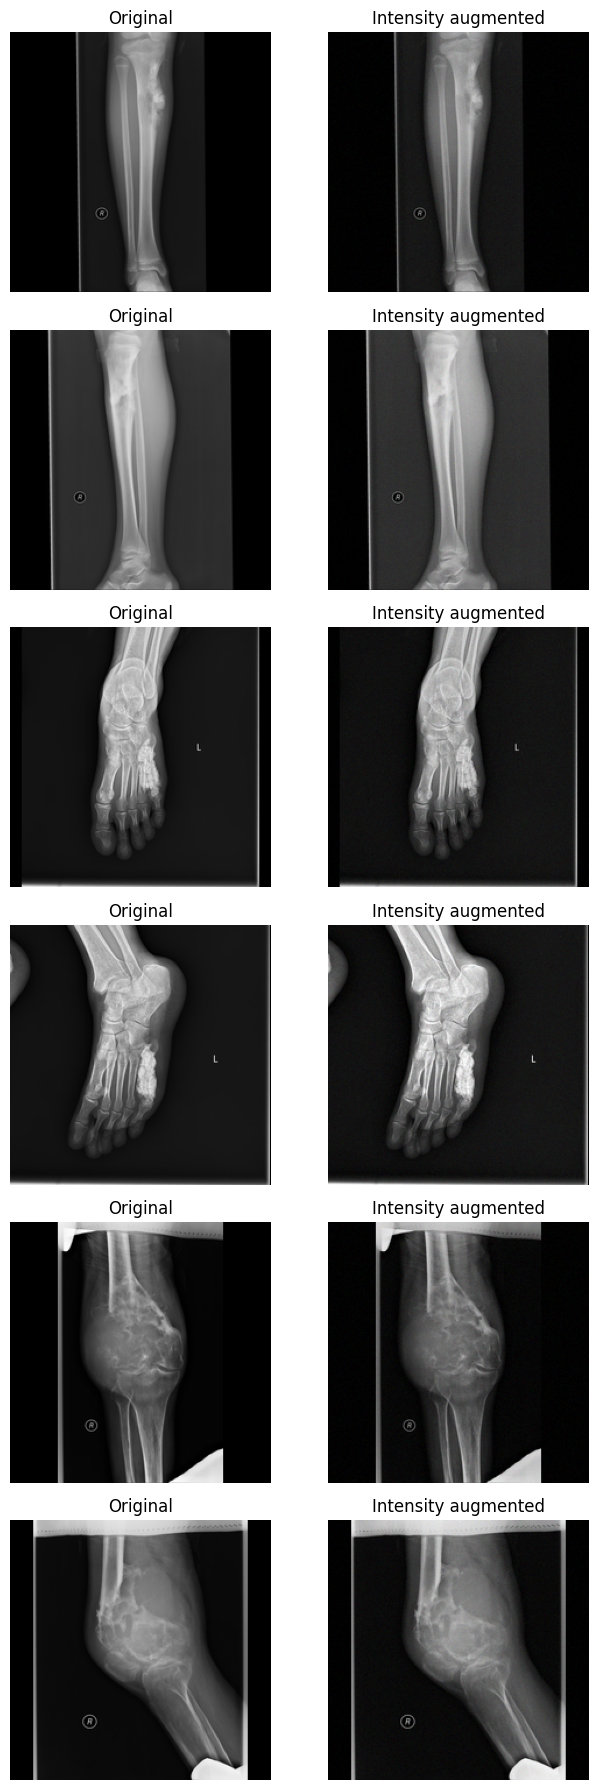

In [19]:
fig, axes = plt.subplots(len(sample_rows), 2, figsize=(7, 3 * len(sample_rows)))

for row_number, (_, row) in enumerate(sample_rows.iterrows()):
    original = Image.open(TRAIN_IMAGE_DIR / row['filename']).convert('RGB')
    augmented = training_transform(original).permute(1, 2, 0).numpy()

    axes[row_number, 0].imshow(original, cmap='gray')
    axes[row_number, 1].imshow(augmented, cmap='gray')
    axes[row_number, 0].set_title('Original')
    axes[row_number, 1].set_title('Intensity augmented')
    axes[row_number, 0].axis('off')
    axes[row_number, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Verify that the original dataset was not changed

We compare the image counts, filenames, and metadata row counts from before and after the visualization. Since augmentation is in memory, these values should stay the same.

In [20]:
after_check = simple_dataset_check()

for split in ['train', 'valid', 'test']:
    assert before_check[split]['image_count'] == after_check[split]['image_count']
    assert before_check[split]['filenames'] == after_check[split]['filenames']
    assert before_check[split]['metadata_rows'] == after_check[split]['metadata_rows']

print('Image counts unchanged.')
print('Filenames unchanged.')
print('Metadata row counts unchanged.')
print('The final dataset was not modified.')

Image counts unchanged.
Filenames unchanged.
Metadata row counts unchanged.
The final dataset was not modified.
